# AGL — RoBERTa Fine-Tuning (Heavy Workload)

**Adaptive Guardrail Layer (AGL) — Binary Prompt Safety Classifier**

Fine-tunes `roberta-base` on the AGL binary dataset with **increased workload** for more training data.
This notebook is designed for **local execution** (NVIDIA GPU with CUDA).

**Data source:** `data/processed/dataset_feature_engineered.csv`

**Differences from baseline (train_roberta_local.ipynb):**
- Max samples per class: 25,000 (vs 15,000 baseline)
- Epochs: 5 (vs 3 baseline)
- Batch size: 48 (vs 32 baseline)
- Early stopping patience: 3 (vs 2 baseline)

In [2]:
# ── 1. Setup ────────────────────────────────────────────────────────────────
import os
import sys

# Set working directory to project root (parent of notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(PROJECT_ROOT)
elif not os.path.exists('src/config.py'):
    if os.path.exists('../src/config.py'):
        os.chdir('..')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f"Working directory: {os.getcwd()}")
assert os.path.exists('src/config.py'), "Not in project root — run from the notebooks/ or project root directory"

Working directory: /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone


In [3]:
# ── 2. Check environment ────────────────────────────────────────────────────
import torch

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")

if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = "mps"
    print(f"Device: MPS (Apple Silicon)")
elif torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"Device: CUDA — {torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print(f"Device: CPU (training will be slow but it works)")

# Verify data exists
data_csv = 'data/processed/dataset_feature_engineered.csv'
assert os.path.exists(data_csv), f"Data not found at {data_csv}. Run the data pipeline notebooks first."
print(f"\nData: {data_csv} ✓")

Python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 10:07:17) [Clang 14.0.6 ]
PyTorch: 2.5.1
Device: MPS (Apple Silicon)

Data: data/processed/dataset_feature_engineered.csv ✓


## Step 3: Build Dataset (Heavy)

Load CSV, deduplicate, balance (25k per class), and split into train/val/test parquets.

In [5]:
# ── 3. Build dataset (HEAVY - 25k per class) ───────────────────────────────
# Override the max samples per class for heavier training
import pandas as pd
from src.config import MAX_SAMPLES_PER_CLASS

# Temporarily override for heavier dataset
original_max = MAX_SAMPLES_PER_CLASS
import src.config as cfg
cfg.MAX_SAMPLES_PER_CLASS = 25000  # Heavy: 25k per class (50k total)

from src.data.build_dataset import build_dataset

splits = build_dataset(csv_path='data/processed/dataset_feature_engineered.csv')

for name, df in splits.items():
    print(f"  {name}: {len(df)} samples")

# Restore original
cfg.MAX_SAMPLES_PER_CLASS = original_max


Building AGL dataset (binary classification)

Loaded 104755 samples from data/processed/dataset_feature_engineered.csv
  Label distribution: {0: 55108, 1: 49647}
  Dedup removed 5665 duplicates

After dedup: 99090 samples

After balancing: 50000 samples
Label distribution:
label_name
Benign       25000
Malicious    25000
Saved train: 34999 samples -> /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/data/processed/train.parquet
Saved val: 7500 samples -> /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/data/processed/val.parquet
Saved test: 7501 samples -> /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/data/processed/test.parquet
Saved metadata -> /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/data/processed/dataset_metadata.json
  train: 34999 samples
  val: 7500 samples
  test: 7501 samples


In [6]:
# ── 3b. Verify dataset ──────────────────────────────────────────────────────
import pandas as pd
from src.config import ID2LABEL

for split in ['train', 'val', 'test']:
    df = pd.read_parquet(f'data/processed/{split}.parquet')
    print(f"\n{split}: {len(df)} samples")
    label_counts = df['label'].value_counts()
    for label_id, count in label_counts.items():
        print(f"  {ID2LABEL[label_id]}: {count}")


train: 34999 samples
  Malicious: 17500
  Benign: 17499

val: 7500 samples
  Malicious: 3750
  Benign: 3750

test: 7501 samples
  Benign: 3751
  Malicious: 3750


## Step 4: Fine-Tune RoBERTa (Heavy)

Train the binary classifier with **heavier workload**:
- LR: 2e-5, warmup: 10%, weight decay: 0.01
- **Batch: 48** (vs 32 baseline)
- **Epochs: 5** (vs 3 baseline)
- **Early stopping patience: 3** (vs 2 baseline)
- Max sequence length: 128
- 2 classes: Benign (0), Malicious (1)

In [8]:
# ── 4. Train RoBERTa classifier (HEAVY) ─────────────────────────────────────
# Override training parameters for heavier workload
import src.config as cfg

# Save original values
orig_batch = cfg.TRAIN_BATCH_SIZE
orig_epochs = cfg.NUM_EPOCHS
orig_patience = cfg.EARLY_STOPPING_PATIENCE

# Apply heavy settings
cfg.TRAIN_BATCH_SIZE = 48      # Larger batch
cfg.NUM_EPOCHS = 5             # More epochs
cfg.EARLY_STOPPING_PATIENCE = 3  # More patience

from src.training.train import train_classifier

best_path = train_classifier()
print(f"\nBest model saved to: {best_path}")

# Restore original
cfg.TRAIN_BATCH_SIZE = orig_batch
cfg.NUM_EPOCHS = orig_epochs
cfg.EARLY_STOPPING_PATIENCE = orig_patience

Map:   0%|          | 0/34999 [00:00<?, ? examples/s]

Tokenized train: 34999 samples


Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

Tokenized val: 7500 samples


Map:   0%|          | 0/7501 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenized test: 7501 samples
Class weights: [1.0000285730613179, 0.9999714285714286]

Starting training: 5 epochs, lr=2e-05


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.250700,0.208281,0.918933,0.918930,0.918930,0.918996,0.918933
2,0.169900,0.185147,0.932133,0.932100,0.932100,0.932972,0.932133
3,0.108100,0.203143,0.931467,0.931435,0.931435,0.932254,0.931467
4,0.072200,0.257259,0.930000,0.930000,0.930000,0.930001,0.930000
5,0.039100,0.322284,0.931867,0.931866,0.931866,0.931886,0.931867



[Epoch 1] val_loss=0.2083  macro_f1=0.9189  accuracy=0.9189

[Epoch 2] val_loss=0.1851  macro_f1=0.9321  accuracy=0.9321

[Epoch 3] val_loss=0.2031  macro_f1=0.9314  accuracy=0.9315

[Epoch 4] val_loss=0.2573  macro_f1=0.9300  accuracy=0.9300

[Epoch 5] val_loss=0.3223  macro_f1=0.9319  accuracy=0.9319

Best model saved → /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/models/classifier/best

Best model saved to: /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/models/classifier/best


## Step 5: Evaluate

Run the full evaluation suite: keyword baseline, TF-IDF/SVM baseline, RoBERTa classifier.

In [10]:
# ── 6. Run evaluation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from src.config import MODELS_DIR, PROCESSED_DIR, RESULTS_DIR
from src.evaluation.metrics import evaluate_predictions, save_results
from src.evaluation.baselines import keyword_blocklist_baseline, tfidf_svm_baseline

# Load test data
train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
y_true = test_df['label'].values

print("=" * 60)
print("Running evaluation suite (HEAVY model)")
print("=" * 60)

all_results = {}

# Baseline 1: Keyword blocklist
print("\n[1/3] Keyword blocklist baseline...")
kw_preds = keyword_blocklist_baseline(test_df)
kw_results = evaluate_predictions(y_true, kw_preds)
all_results['keyword_blocklist'] = kw_results
print(f"  Macro-F1: {kw_results['macro_f1']:.4f}")

# Baseline 2: TF-IDF + SVM
print("\n[2/3] TF-IDF + LinearSVM baseline...")
svm_preds, _ = tfidf_svm_baseline(train_df, test_df)
svm_results = evaluate_predictions(y_true, svm_preds)
all_results['tfidf_svm'] = svm_results
print(f"  Macro-F1: {svm_results['macro_f1']:.4f}")

# RoBERTa
checkpoint = MODELS_DIR / 'classifier' / 'best'
if checkpoint.exists():
    print("\n[3/3] RoBERTa classifier (HEAVY)...")
    from src.models.agl_pipeline import AGLPipeline
    pipeline = AGLPipeline.from_checkpoint(checkpoint)
    roberta_preds = np.array([pipeline.predict(t).label_id for t in test_df['text']])
    roberta_results = evaluate_predictions(y_true, roberta_preds)
    all_results['roberta_heavy'] = roberta_results
    print(f"  Macro-F1: {roberta_results['macro_f1']:.4f}")
else:
    print(f"\n[3/3] Skipping RoBERTa — no checkpoint at {checkpoint}")

save_results(all_results, 'evaluation_results_heavy', RESULTS_DIR)

print("\n" + "=" * 60)
print("Summary — Macro-F1 Scores:")
print("=" * 60)
for method, res in all_results.items():
    print(f"  {method:25s} {res['macro_f1']:.4f}")

Running evaluation suite (HEAVY model)

[1/3] Keyword blocklist baseline...
  Macro-F1: 0.3690

[2/3] TF-IDF + LinearSVM baseline...
  Macro-F1: 0.8639

[3/3] RoBERTa classifier (HEAVY)...
  Macro-F1: 0.9258
Saved results → /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/results/evaluation_results_heavy.json

Summary — Macro-F1 Scores:
  keyword_blocklist         0.3690
  tfidf_svm                 0.8639
  roberta_heavy             0.9258


## Step 6: Visualizations

Generate figures: confusion matrix, F1 comparison, ROC curve.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Saved → /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/results/figures/confusion_matrix_roberta_heavy.png
Saved → /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/results/figures/f1_comparison_heavy.png
Saved → /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/results/figures/roc_curve_roberta_heavy.png

RoBERTa (Heavy) Results:
  Macro-F1:  0.9258
  ROC-AUC:   0.9769639740513641
  PR-AUC:    0.980436470469078

Latency: mean=69.0ms, p99=78.5ms
Saved results → /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/results/roberta_heavy_evaluation.json

All figures saved to: /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/results/figures


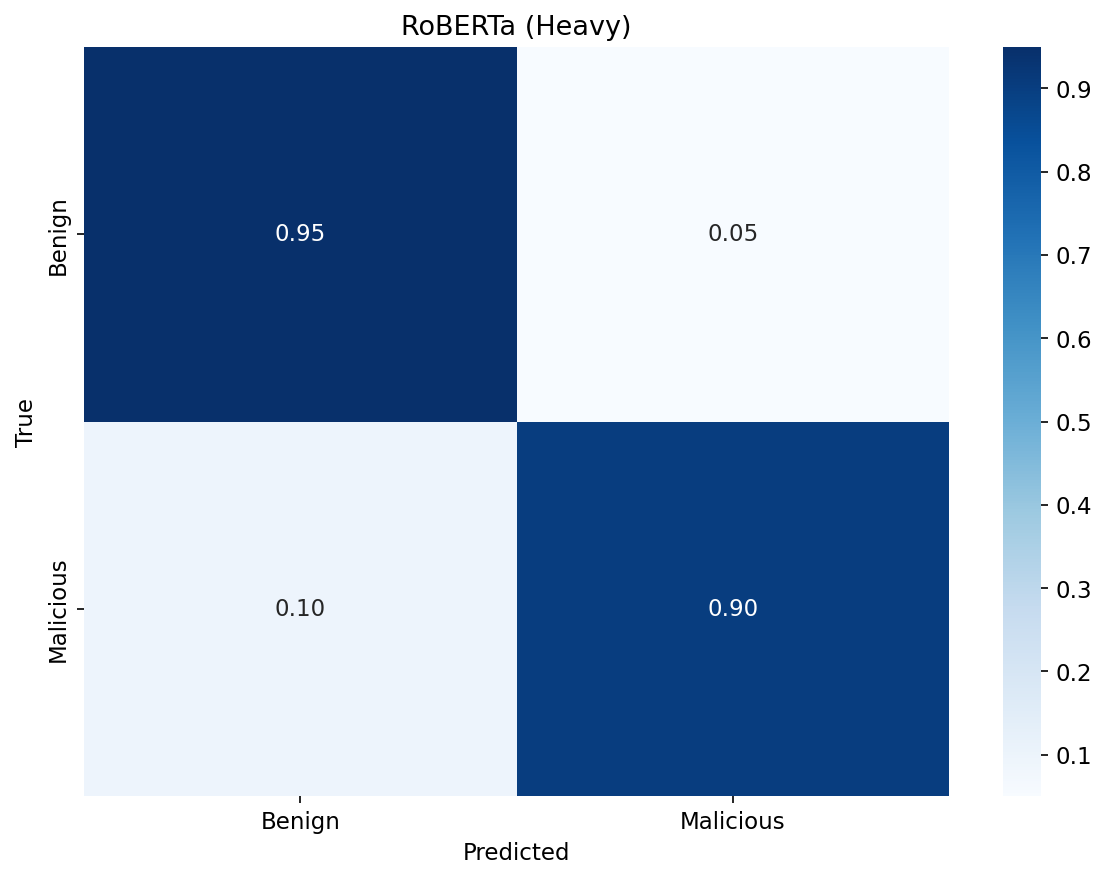

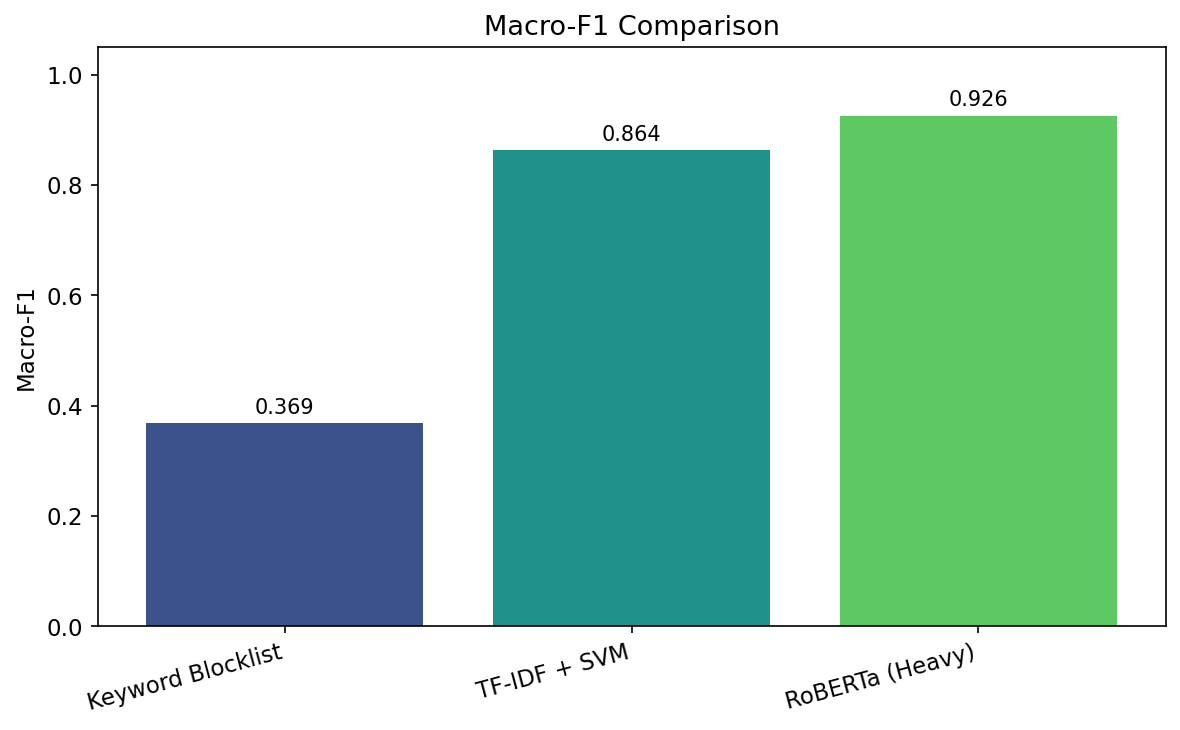

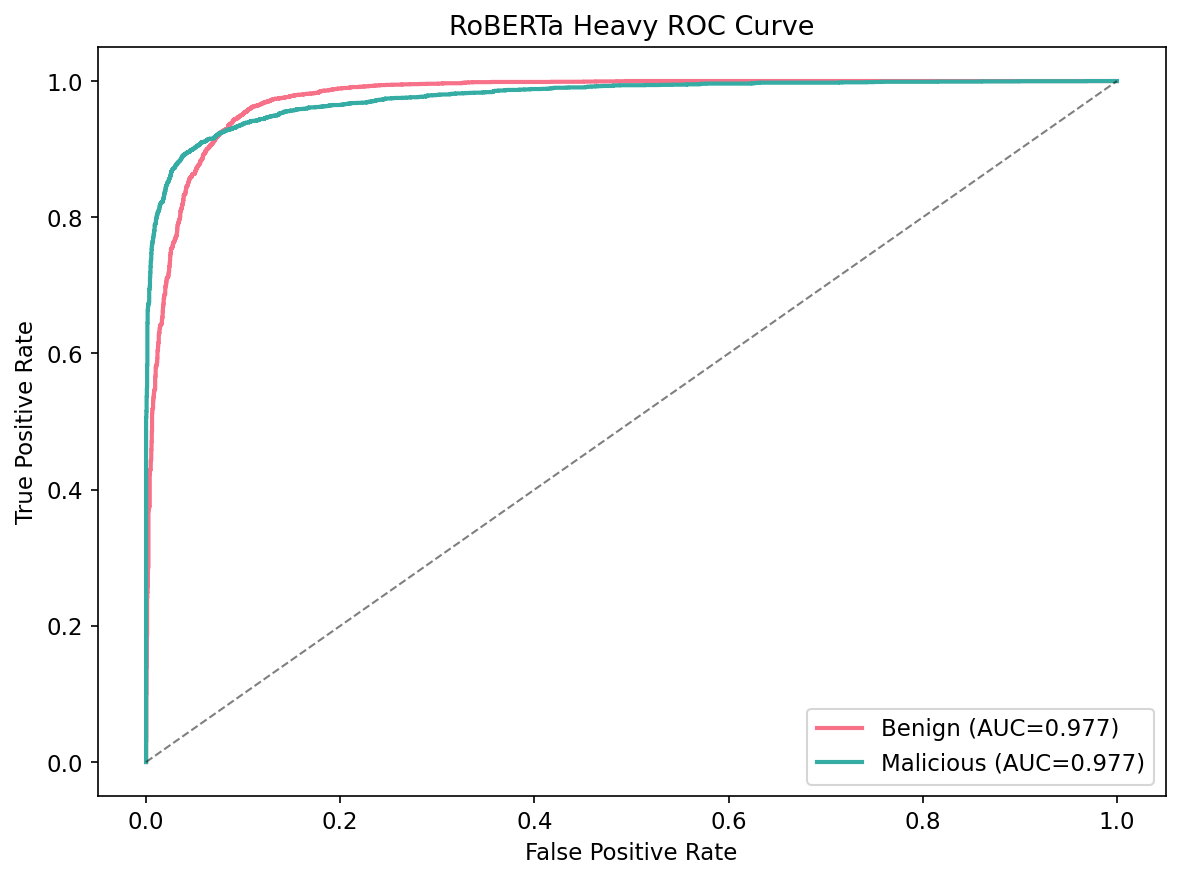

In [12]:
# ── 7. Generate visualizations ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
from src.config import RESULTS_DIR, FIGURES_DIR, PROCESSED_DIR, MODELS_DIR, MAX_SEQ_LENGTH
from src.evaluation.visualizations import (
    plot_confusion_matrix, plot_f1_comparison, plot_roc_curves
)
from src.evaluation.metrics import evaluate_predictions, benchmark_latency, save_results
from src.evaluation.baselines import keyword_blocklist_baseline, tfidf_svm_baseline
from src.models.agl_pipeline import AGLPipeline
from transformers import AutoTokenizer

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load test data
test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
y_true = test_df['label'].values

# Baselines
kw_preds = keyword_blocklist_baseline(test_df)
svm_preds, _ = tfidf_svm_baseline(train_df, test_df)

# RoBERTa predictions + probabilities (for ROC-AUC)
checkpoint = MODELS_DIR / 'classifier' / 'best'
pipeline = AGLPipeline.from_checkpoint(checkpoint)
tokenizer = AutoTokenizer.from_pretrained(str(checkpoint), local_files_only=True)

roberta_preds = []
roberta_probs = []
for text in test_df['text']:
    pred = pipeline.predict(text)
    roberta_preds.append(pred.label_id)
    inputs = tokenizer(text, truncation=True, padding='max_length',
                       max_length=MAX_SEQ_LENGTH, return_tensors='pt')
    inputs = {k: v.to(pipeline.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = pipeline.model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    roberta_probs.append(probs)

roberta_preds = np.array(roberta_preds)
roberta_probs = np.array(roberta_probs)

# ── Confusion matrix ──
plot_confusion_matrix(y_true, roberta_preds, title='RoBERTa (Heavy)',
                      save_path=FIGURES_DIR / 'confusion_matrix_roberta_heavy.png')

# ── F1 comparison ──
from sklearn.metrics import f1_score
f1_results = {
    'Keyword Blocklist': f1_score(y_true, kw_preds, average='macro', zero_division=0),
    'TF-IDF + SVM': f1_score(y_true, svm_preds, average='macro', zero_division=0),
    'RoBERTa (Heavy)': f1_score(y_true, roberta_preds, average='macro', zero_division=0),
}
plot_f1_comparison(f1_results, save_path=FIGURES_DIR / 'f1_comparison_heavy.png')

# ── ROC Curve ──
plot_roc_curves(y_true, roberta_probs, title='RoBERTa Heavy ROC Curve',
                save_path=FIGURES_DIR / 'roc_curve_roberta_heavy.png')

# ── Full evaluation with AUC ──
results = evaluate_predictions(y_true, roberta_preds, y_prob=roberta_probs)
print(f"\nRoBERTa (Heavy) Results:")
print(f"  Macro-F1:  {results['macro_f1']:.4f}")
print(f"  ROC-AUC:   {results.get('roc_auc', 'N/A')}")
print(f"  PR-AUC:    {results.get('pr_auc', 'N/A')}")

# ── Latency ──
latency = benchmark_latency(pipeline, test_df['text'].head(50).tolist(), n_runs=2)
print(f"\nLatency: mean={latency['mean_ms']:.1f}ms, p99={latency['p99_ms']:.1f}ms")

# ── Save results JSON ──
all_results = {
    'roberta_heavy': {**results, 'latency': latency}
}
save_results(all_results, 'roberta_heavy_evaluation', RESULTS_DIR)
print('\nAll figures saved to:', FIGURES_DIR)

## Step 7: Done

Model checkpoint saved to `models/classifier/best/`, results to `results/`.

In [14]:
# ── 7. Summary ──────────────────────────────────────────────────────────────
from pathlib import Path

print("Heavy Training Complete!")
print("Artifacts saved locally:")
for p in ['models/classifier/best', 'results']:
    exists = "✓" if Path(p).exists() else "✗"
    print(f"  {exists} {p}")

print("\nComparison with baseline:")
print("  Baseline (train_roberta_local.ipynb): 15k samples/class, 3 epochs, batch 32")
print("  Heavy (this notebook): 25k samples/class, 5 epochs, batch 48")

Heavy Training Complete!
Artifacts saved locally:
  ✓ models/classifier/best
  ✓ results

Comparison with baseline:
  Baseline (train_roberta_local.ipynb): 15k samples/class, 3 epochs, batch 32
  Heavy (this notebook): 25k samples/class, 5 epochs, batch 48


## Step 8: Export Additional API Artifacts

This section adds deployment-focused export files for the FastAPI classification endpoint without changing the training flow.

It writes the following files into `models/classifier/best/`:

- `label_mapping.json`
- `inference_config.json`
- `classification_threshold.json`

It also validates that the checkpoint directory already contains the expected model and tokenizer files required for `AutoTokenizer.from_pretrained(...)` and `AutoModelForSequenceClassification.from_pretrained(...)`.


In [16]:

# ── 8. Export additional API artifacts ──────────────────────────────────────
import json
from pathlib import Path

from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer

import src.config as cfg

checkpoint_dir = Path("../models/classifier/best")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

assert checkpoint_dir.exists(), f"Checkpoint directory not found: {checkpoint_dir}"

print(f"Preparing API export artifacts in: {checkpoint_dir.resolve()}")

# ---------------------------------------------------------------------------
# 1) Resolve label mappings
# ---------------------------------------------------------------------------
id2label = None
label2id = None

if hasattr(cfg, "ID2LABEL"):
    raw_id2label = cfg.ID2LABEL
    if isinstance(raw_id2label, dict):
        id2label = {str(k): str(v) for k, v in raw_id2label.items()}
    elif isinstance(raw_id2label, (list, tuple)):
        id2label = {str(i): str(v) for i, v in enumerate(raw_id2label)}

if hasattr(cfg, "LABEL2ID"):
    raw_label2id = cfg.LABEL2ID
    if isinstance(raw_label2id, dict):
        label2id = {str(k): int(v) for k, v in raw_label2id.items()}

if id2label is None and label2id is not None:
    id2label = {str(v): str(k) for k, v in label2id.items()}

if label2id is None and id2label is not None:
    label2id = {str(v): int(k) for k, v in id2label.items()}

if id2label is None or label2id is None:
    # Fallback for binary setup used in this notebook
    id2label = {"0": "benign", "1": "malicious"}
    label2id = {"benign": 0, "malicious": 1}

label_mapping = {
    "id2label": id2label,
    "label2id": label2id,
}

label_mapping_path = checkpoint_dir / "label_mapping.json"
with open(label_mapping_path, "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, indent=2)

print(f"Saved: {label_mapping_path}")

# ---------------------------------------------------------------------------
# 2) Validate checkpoint has model + tokenizer files
# ---------------------------------------------------------------------------
config_path = checkpoint_dir / "config.json"
assert config_path.exists(), (
    f"Missing {config_path}. The classifier checkpoint must be saved with "
    f"Hugging Face save_pretrained()."
)

# Try loading model/tokenizer directly from the checkpoint to confirm the
# endpoint will be able to do the same.
loaded_config = AutoConfig.from_pretrained(checkpoint_dir, local_files_only=True)
loaded_tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir, local_files_only=True)
loaded_model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint_dir,
    local_files_only=True,
)

print("Checkpoint validation passed:")
print(f"  model_type: {getattr(loaded_config, 'model_type', 'unknown')}")
print(f"  num_labels: {getattr(loaded_config, 'num_labels', 'unknown')}")

# ---------------------------------------------------------------------------
# 3) Save inference metadata for the API
# ---------------------------------------------------------------------------
max_seq_length = getattr(cfg, "MAX_SEQ_LENGTH", 128)
problem_type = getattr(loaded_config, "problem_type", None) or "single_label_classification"
num_labels = int(getattr(loaded_config, "num_labels", len(id2label)))

# Prefer label names from config if available
classes = [id2label[str(i)] for i in range(num_labels) if str(i) in id2label]

inference_config = {
    "model_type": "roberta_sequence_classification",
    "checkpoint_dir": str(checkpoint_dir.as_posix()),
    "problem_type": problem_type,
    "num_labels": num_labels,
    "max_seq_length": int(max_seq_length),
    "classes": classes,
    "id2label": id2label,
    "label2id": label2id,
    "tokenizer_class": loaded_tokenizer.__class__.__name__,
    "transformers_model_type": getattr(loaded_config, "model_type", "roberta"),
}

inference_config_path = checkpoint_dir / "inference_config.json"
with open(inference_config_path, "w", encoding="utf-8") as f:
    json.dump(inference_config, f, indent=2)

print(f"Saved: {inference_config_path}")

# ---------------------------------------------------------------------------
# 4) Save optional confidence threshold metadata
# ---------------------------------------------------------------------------
# This is optional for the API, but useful if you want the endpoint to support
# "uncertain" decisions later. For now we store a default value.
classification_threshold = {
    "min_confidence": 0.50,
    "decision_rule": "argmax",
    "notes": "Default export value. Adjust after calibration if desired."
}

classification_threshold_path = checkpoint_dir / "classification_threshold.json"
with open(classification_threshold_path, "w", encoding="utf-8") as f:
    json.dump(classification_threshold, f, indent=2)

print(f"Saved: {classification_threshold_path}")

# ---------------------------------------------------------------------------
# 5) Print final artifact inventory for API deployment
# ---------------------------------------------------------------------------
print("\nArtifacts now available for classification API deployment:")
for p in sorted(checkpoint_dir.iterdir()):
    print(f"  - {p.name}")


Preparing API export artifacts in: /Users/apadin/Desktop/Capstone/aai-590-group-8-capstone/models/classifier/best
Saved: models/classifier/best/label_mapping.json
Checkpoint validation passed:
  model_type: roberta
  num_labels: 2
Saved: models/classifier/best/inference_config.json
Saved: models/classifier/best/classification_threshold.json

Artifacts now available for classification API deployment:
  - classification_threshold.json
  - config.json
  - inference_config.json
  - label_mapping.json
  - merges.txt
  - model.safetensors
  - special_tokens_map.json
  - tokenizer.json
  - tokenizer_config.json
  - training_args.bin
  - vocab.json
